Task 1

Dataset size: 60000
Train size: 48000
Test size: 12000
Image shape: torch.Size([1, 28, 28])
Data type: torch.float32


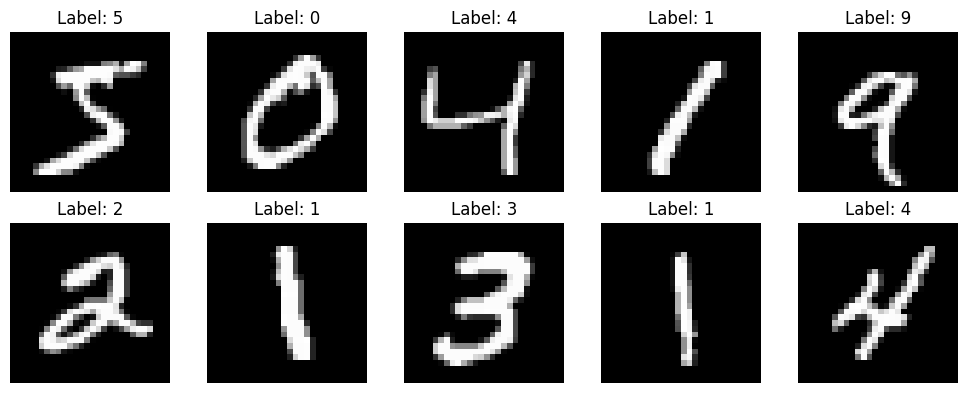

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.MNIST(
    root="C:\\Users\\alias\\Downloads\\Lab9_dataset",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

sample_img, sample_label = dataset[0]

print("Dataset size:", len(dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Image shape:", sample_img.shape)
print("Data type:", sample_img.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Task 2

In [ ]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 28*28)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        z = self.relu(self.fc1(z))
        z = self.relu(self.fc2(z))
        z = self.sigmoid(self.fc3(z))
        
        z = z.view(-1, 1, 28, 28)
        return z


class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        
        return reconstruction, mu, logvar

# Инициализация модели
latent_dim = 2
model = VAE(latent_dim)

print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)
print("Latent dimension:", latent_dim)

VAE(
  (encoder): Encoder(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (fc_mu): Linear(in_features=128, out_features=2, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=2, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=256, bias=True)
    (fc3): Linear(in_features=256, out_features=784, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  )
)
Trainable parameters: 469268
Latent dimension: 2


Task 3

In [4]:
import torch.nn.functional as F

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + kl_loss
    
    return total_loss, recon_loss, kl_loss

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for images, _ in train_loader:
    images = images.to(device)

    recon, mu, logvar = model(images)

    loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)

    print(f"Total: {loss.item():.2f}, Recon: {recon_loss.item():.2f}, KL: {kl_loss.item():.2f}")
    
    break

Total: 69660.39, Recon: 69659.53, KL: 0.86


Task 4

In [6]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20

train_losses = []
test_losses = []

train_recon_losses = []
train_kl_losses = []

test_recon_losses = []
test_kl_losses = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_recon = 0
    train_kl = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)

    # ===== TEST =====
    model.eval()
    test_loss = 0
    test_recon = 0
    test_kl = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            recon, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar)

            test_loss += loss.item()
            test_recon += recon_loss.item()
            test_kl += kl_loss.item()

    test_losses.append(test_loss)
    test_recon_losses.append(test_recon)
    test_kl_losses.append(test_kl)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.2f} | Recon: {train_recon:.2f} | KL: {train_kl:.2f}")
    print(f"Test  Loss: {test_loss:.2f} | Recon: {test_recon:.2f} | KL: {test_kl:.2f}")

Epoch [1/20]
Train Loss: 9375267.01 | Recon: 9188928.42 | KL: 186338.59
Test  Loss: 2033773.11 | Recon: 1974514.84 | KL: 59258.27
Epoch [2/20]
Train Loss: 7971919.04 | Recon: 7733059.38 | KL: 238859.66
Test  Loss: 1946544.70 | Recon: 1886423.79 | KL: 60120.92
Epoch [3/20]
Train Loss: 7695218.33 | Recon: 7442483.20 | KL: 252735.15
Test  Loss: 1900699.88 | Recon: 1834025.34 | KL: 66674.54
Epoch [4/20]
Train Loss: 7527327.18 | Recon: 7266806.72 | KL: 260520.47
Test  Loss: 1871752.72 | Recon: 1805542.31 | KL: 66210.41
Epoch [5/20]
Train Loss: 7420122.14 | Recon: 7153098.61 | KL: 267023.52
Test  Loss: 1841972.35 | Recon: 1774247.38 | KL: 67724.96
Epoch [6/20]
Train Loss: 7340454.84 | Recon: 7068611.96 | KL: 271842.89
Test  Loss: 1828255.68 | Recon: 1758703.16 | KL: 69552.52
Epoch [7/20]
Train Loss: 7273266.22 | Recon: 6995621.58 | KL: 277644.63
Test  Loss: 1817056.04 | Recon: 1746459.98 | KL: 70596.05
Epoch [8/20]
Train Loss: 7216800.88 | Recon: 6934530.09 | KL: 282270.81
Test  Loss: 180569

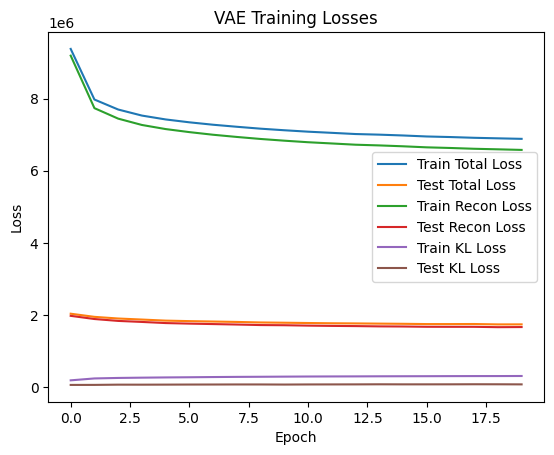

In [7]:
plt.figure()

# Total loss
plt.plot(train_losses, label="Train Total Loss")
plt.plot(test_losses, label="Test Total Loss")

# Reconstruction
plt.plot(train_recon_losses, label="Train Recon Loss")
plt.plot(test_recon_losses, label="Test Recon Loss")

# KL
plt.plot(train_kl_losses, label="Train KL Loss")
plt.plot(test_kl_losses, label="Test KL Loss")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")

plt.show()

Task 5

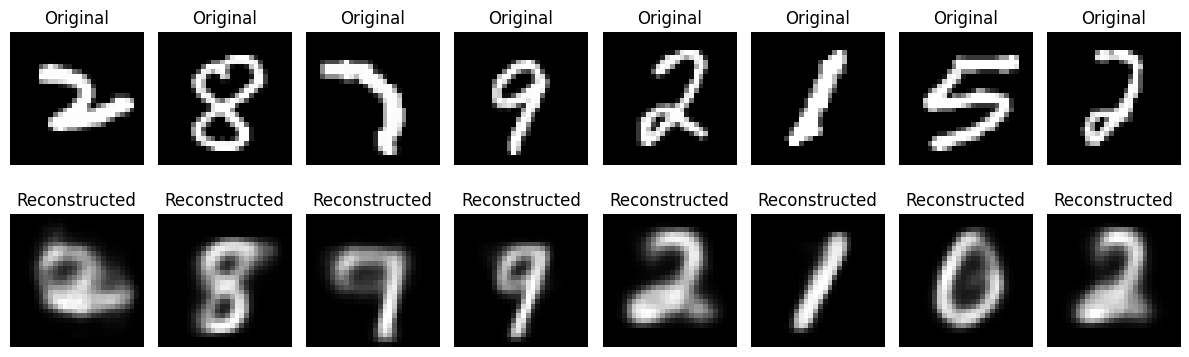

In [8]:
model.eval()

images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    recon, _, _ = model(images)

images = images.cpu()
recon = recon.cpu()

# Визуализация
n = 8
plt.figure(figsize=(12, 4))

for i in range(n):
    # Оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Реконструкция
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
total_recon_loss = 0

model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        recon, mu, logvar = model(images)

        _, recon_loss, _ = vae_loss(recon, images, mu, logvar)
        total_recon_loss += recon_loss.item()

avg_recon_loss = total_recon_loss / len(test_loader.dataset)
print("Average Reconstruction Loss:", avg_recon_loss)

Average Reconstruction Loss: 138.6096708984375


In [10]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x.view(-1, 1, 28, 28)

In [11]:
ae = Autoencoder().to(device)
optimizer_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)

for epoch in range(10):
    for images, _ in train_loader:
        images = images.to(device)

        optimizer_ae.zero_grad()
        recon = ae(images)

        loss = F.binary_cross_entropy(recon, images, reduction='sum')
        loss.backward()
        optimizer_ae.step()

Task 6

In [12]:
model.eval()

latent_vectors = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        mu, _ = model.encoder(images)  # берём только mean
        
        latent_vectors.append(mu.cpu())
        labels_list.append(labels)

latent_vectors = torch.cat(latent_vectors).numpy()
labels_list = torch.cat(labels_list).numpy()

print("Latent shape:", latent_vectors.shape)

Latent shape: (12000, 2)


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

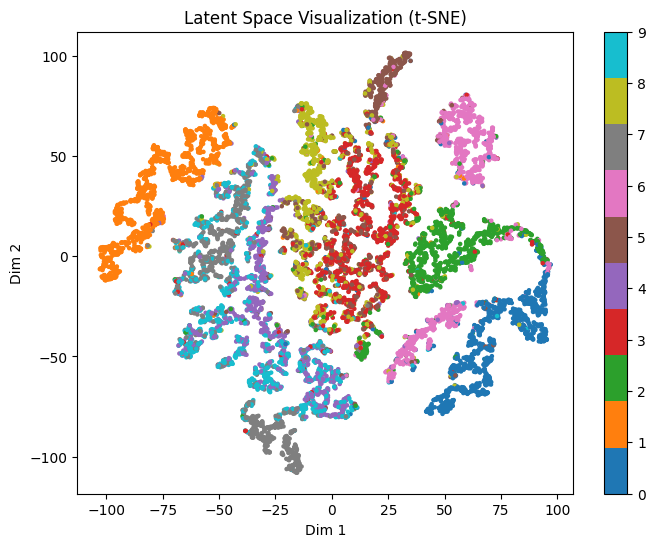

In [15]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=labels_list,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

Task 7

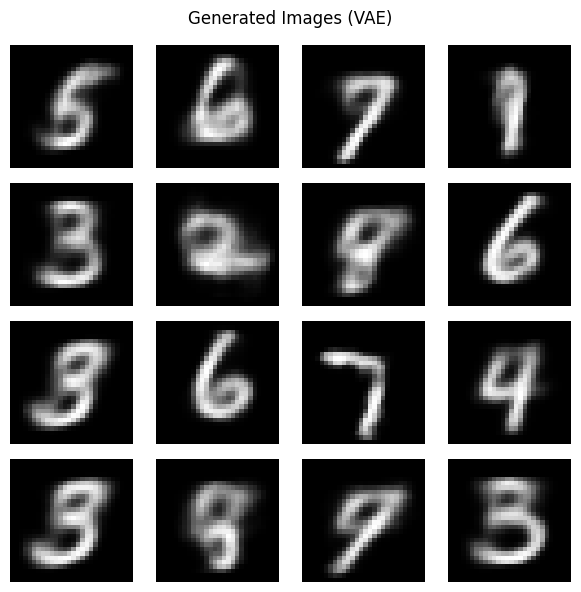

In [ ]:
model.eval()

num_samples = 16
latent_dim = 2  # тот же, что использовал

# Сэмплируем из N(0,1)
z = torch.randn(num_samples, latent_dim).to(device)

with torch.no_grad():
    generated = model.decoder(z)

generated = generated.cpu()

# Визуализация
plt.figure(figsize=(6, 6))

for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Images (VAE)")
plt.tight_layout()
plt.show()

Task 8

In [17]:
model.eval()

images, _ = next(iter(test_loader))
images = images.to(device)

img1 = images[0].unsqueeze(0)
img2 = images[1].unsqueeze(0)

with torch.no_grad():
    mu1, _ = model.encoder(img1)
    mu2, _ = model.encoder(img2)

In [18]:
num_steps = 10
alphas = torch.linspace(0, 1, num_steps).to(device)

interpolated_images = []

with torch.no_grad():
    for alpha in alphas:
        z = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decoder(z)
        interpolated_images.append(recon.cpu())

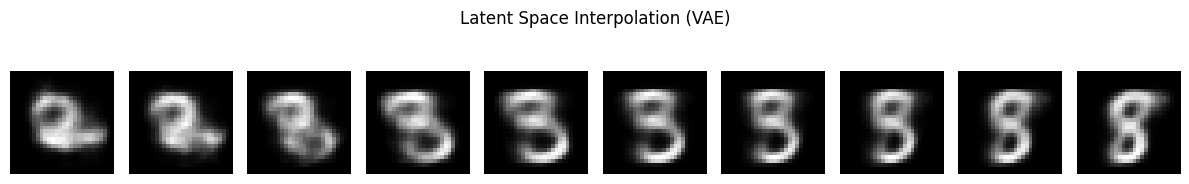

In [19]:
plt.figure(figsize=(12, 2))

for i in range(num_steps):
    plt.subplot(1, num_steps, i + 1)
    plt.imshow(interpolated_images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Latent Space Interpolation (VAE)")
plt.tight_layout()
plt.show()

Task 9

In [25]:
def vae_loss_beta(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

In [29]:
print("Recon shape:", recon.shape)
print("Images shape:", images.shape)

Recon shape: torch.Size([128, 1, 28, 28])
Images shape: torch.Size([128, 1, 28, 28])


In [30]:
img = images[0].unsqueeze(0)

recon, mu, logvar = model(img)

loss, recon_loss, kl_loss = vae_loss_beta(
    recon, img, mu, logvar, beta=0.1
)

In [ ]:
recon, mu, logvar = model(images)  # images = batch

loss, recon_loss, kl_loss = vae_loss_beta(
    recon, images, mu, logvar, beta=0.1
)